# Principal Component Analysis

## Import bibliotek

In [51]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap  
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

## Analiza zbioru danych New York Times

1. Załaduj zbiór danych NYT jako DataFrame (biblioteka Pandas)
2. Wyświetl 20 losowych wybranych elementów słownika (nagłówek)
3. Dokonaj transformacji PCA pomijając kolumny, które nie reprezentują
słów a jedynie metadane

In [52]:
df = pd.read_csv('./nyt-frame.csv', header = 0)
data = df.iloc[:, 9:]
array = data.values

header = list(df.columns.values[9:])
sample_world = np.random.choice(header, 20, replace = False)
print(sample_world)

pca = PCA()
X_pca = pca.fit_transform(array)

['alive' 'star' 'believes' 'smoke' 'naked' 'everyday' 'size' 'noise'
 'disk' 'nine' 'greek' 'creations' 'heroic' 'cool' 'bull' 'last' 'warhol'
 'books' 'alternate' 'invited']


4. Dla pierwszego komponentu wiodącego wyświetl 15 elementów o najwięszej wartości (wraz z nazwami kolumn - słowami). Jakim słowom odpowiadają największe wartości pierwszego komponentu wiodącego?

5. Dla pierwszego komponentu wiodącego wyświetl 15 elementów o najmniejszej wartości (wraz z nazwami kolumn - słowami). Jakim słowom odpowiadają najmniejsze wartości pierwszego komponentu wiodącego?

In [53]:
pc1 = pca.components_[0]
idx_max = np.argsort(pc1)[-15:]
idx_min = np.argsort(pc1)[:15]

print("Top 15 +PC1 words:", [header[i] for i in idx_max])
print("Top 15 -PC1 words:", [header[i] for i in idx_min])

Top 15 +PC1 words: ['me', 'he', 'mrs', 'im', 'paintings', 'process', 'painting', 'my', 'cooper', 'mother', 'said', 'i', 'ms', 'her', 'she']
Top 15 -PC1 words: ['music', 'trio', 'theater', 'orchestra', 'composers', 'opera', 'theaters', 'm', 'program', 'players', 'festival', 'east', 'y', 'jersey', 'symphony']


Największe wartości PC1 są związane ze sztuką, natomiast najmniejsze wartości PC1 dotyczą muzyki.

6. Powtórz eksperyment dla drugiego komponentu wiodącego. Skomentuj
uzyskane wyniki.

In [54]:
pc2 = pca.components_[1]
idx_max2 = np.argsort(pc2)[-15:]
idx_min2 = np.argsort(pc2)[:15]

print("Top 15 +PC2 words:", [header[i] for i in idx_max2])
print("Top 15 -PC2 words:", [header[i] for i in idx_min2])

Top 15 +PC2 words: ['vocal', 'orchestra', 'songs', 'musical', 'music', 'festival', 'production', 'sang', 'hour', 'i', 'ms', 'opera', 'theater', 'she', 'her']
Top 15 -PC2 words: ['art', 'museum', 'images', 'artists', 'donations', 'museums', 'painting', 'tax', 'paintings', 'sculpture', 'gallery', 'sculptures', 'painted', 'white', 'service']


Największe wartości PC2 są związane z występami scenicznymi, z muzyką i teatrem, natomiast najmniejsze wartości PC2 dotyczą galerii i muzeów jako instytucji i ich działalności.

7. Dokonaj wizualizacji wektorów cech zrzutowanych na 2(3) pierwsze komponenty wiodące. Zaznacz dwie klasy (art, music) oddzielnymi kolorami.

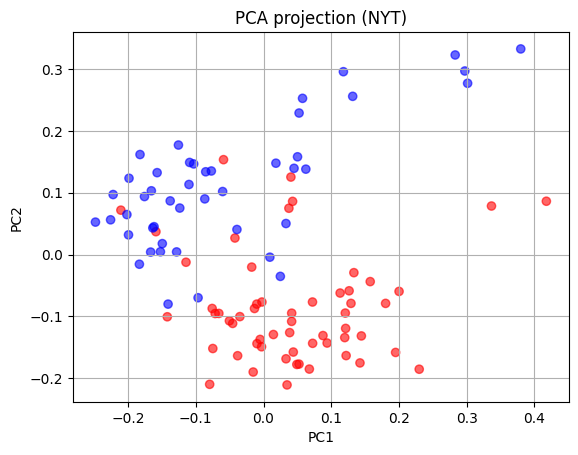

In [55]:
labels = df['class.labels'].values
colors = ['red' if l == 'art' else 'blue' for l in labels]

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6)
plt.title("PCA projection (NYT)")
plt.xlabel("PC1")
plt.ylabel ("PC2")
plt.grid(True)
plt.show()

8. Narysuj wykres zależności wartości wariancji od numeru kierunku wiodącego k. Jaka część wariancji zostaje zachowana po wykonaniu projekcji na pierwsze 10 komponentów wiodących?

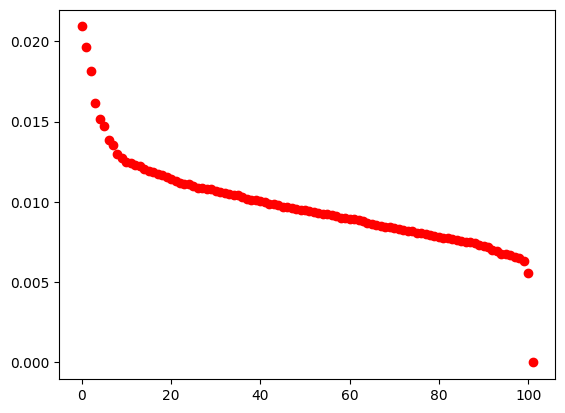

0.15773478029003496


In [56]:
variance_ratio = pca.explained_variance_ratio_
plt.plot(variance_ratio, 'ro')
plt.show()

print(sum(variance_ratio[0:10]))

Po wykonaniu projekcji na pierwsze 10 komponentów wiodących, zachowane zostaje około 15,77% wariancji.

9. Skomentuj w jaki sposób inne niż domyśle wartości argumentów konstruktora sklearn.decomposition.PCA mogą być przydatne w rozwiązaniu
tego zadania:
* n components: None, int, float, ’mle’
* copy
* whiten
* svd solver: ’auto’, ’full’, ’arpack’, ’randomized’

W bibliotece `scikit-learn` domyślne ustawienie PCA wykonuje pełne obliczenia dla wszystkich komponentów. Przy dużych zbiorach danych zmiana domyślnych argumentów pozwala na znaczną optymalizację pamięciową i obliczeniową:

* `n_components` (określa liczbę zachowanych komponentów):
    * **int**: ogranicza obliczenia tylko do podanej liczby pierwszych składowych wiodących, co drastycznie skraca czas działania algorytmu
    * **float**: wyznacza docelowy ułamek wariancji do zachowania np 85%. Algorytm sam dobiera minimalną wymaganą liczbę komponentów
    * **'mle'**: szacuje optymalną liczbę wymiarów za pomocą metody największej wiarygodności

* `copy` (domyślnie True):
    * ustawienie **copy=False** powoduje nadpisanie oryginalnych danych w pamięci, zamiast tworzenia kopii w pamięci RAM. Pozwala to uniknąć błędu out of memory przy bardzo dużych zbiorach tekstowych

* `whiten` (domyślnie False):
    * ustawienie **whiten=True** standaryzuje wyniki, dzieląc je przez wartości osobliwe. Zapewnia to, że każdy nowy komponent ma wariancję równą 1. Proces "wybielania" usuwa informację o pierwotnych proporcjach rozrzutu danych pomiędzy komponentami, ale może to znacząco poprawić dokładność innych modeli uczenia maszynowego, które na wejściu wymagają ustandaryzowanych i nieskorelowanych danych

* `svd_solver` (algorytm obliczający SVD, domyślnie 'auto'):
    * **'auto'**: automatycznie dobiera najwydajniejszy solver ('full', 'randomized' lub 'covariance_eigh') na podstawie rozmiaru danych wejściowych i liczby żądanych komponentów
    * **'full'**: oblicza dokładne, pełne SVD. Przy dużej ilości wymiarów jest bardzo wolne. Jest wymuszane automatycznie, gdy parametr 'n_components' ustawiono na 'mle' lub jako ułamek oczekiwanej wariancji (0 < n_components < 1)
    * **'arpack'**: oblicza tzw. ucięte SVD. Zamiast wyznaczać wszystkie możliwe osie macierzy, algorytm przerywa obliczenia w momencie znalezienia żądanej przez nas liczby komponentów. Dzięki odcięciu zbędnych obliczeń drastycznie oszczędza czas i pamięć
    * **'randomized'**: zrandomizowane SVD. Wykorzystuje losowe próbkowanie do wstępnej kompresji macierzy - zostawia tylko podprzestrzeń o największej wariancji - po czym wykonuje na niej SVD. Znazcnie zmniejsza to złożoność obliczeniową i zużycie pamięci, co czyni ją najszybszą metodą dla ogromnych zbiorów danych

10. ⋆ Porównaj metody t-SNE oraz UMAP z PCA (wizualizacja 2D). Czy nieliniowe metody (np. UMAP) lepiej separują klasy w danych NYT niż PCA?

c:\Users\karol\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


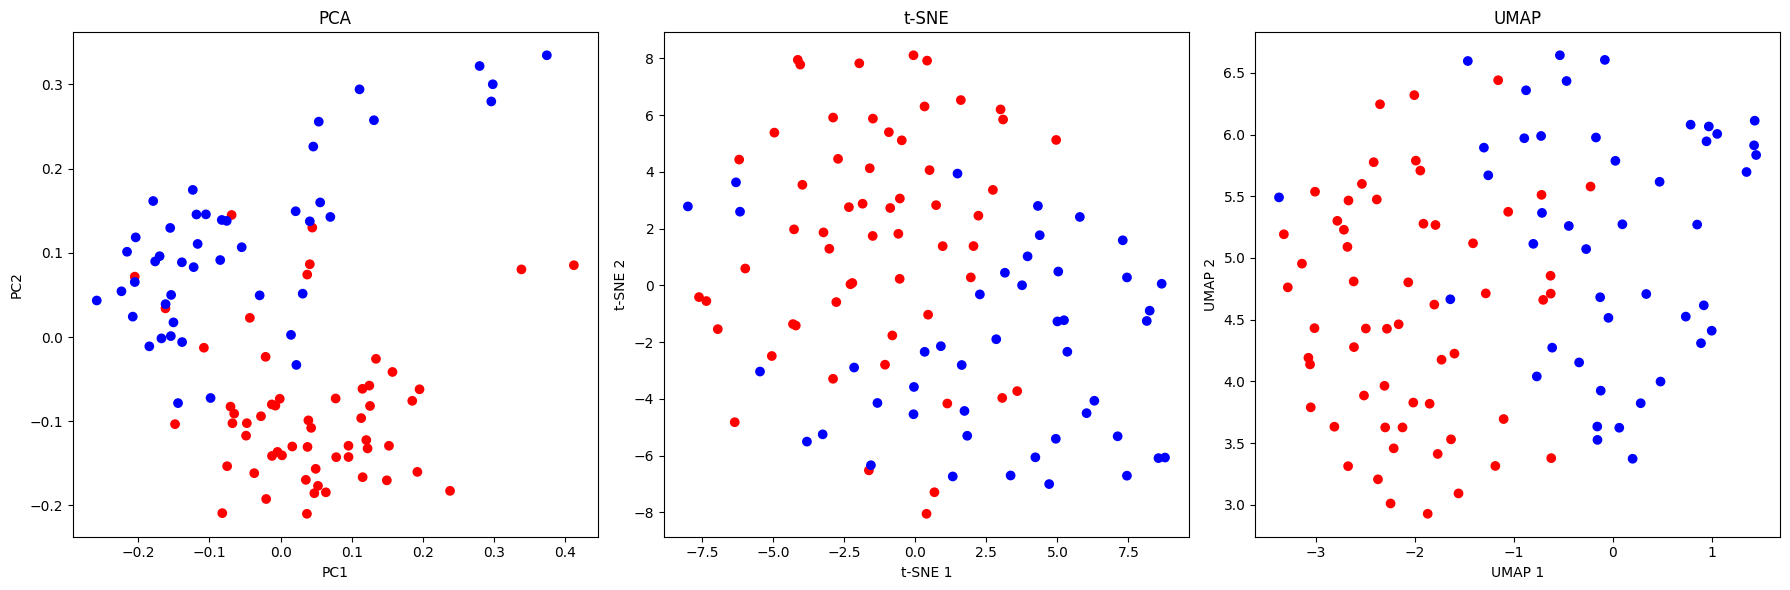

In [57]:
def plot_all_projections(X, colors):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors)
    axes[0].set_title('PCA')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X)
    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors)
    axes[1].set_title('t-SNE')
    axes[1].set_xlabel('t-SNE 1')
    axes[1].set_ylabel('t-SNE 2')
    
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=colors)
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    
    plt.tight_layout()
    plt.show()

plot_all_projections(array, colors)

Nieliniowe metody **t-SNE** oraz **UMAP** wydają się lepiej separować klasy w danych NYT niż **PCA**. W **PCA** klasy są "wymieszane" w centralnej części wykresu. Chociaż widać ogólny trend, nie da się narysować prostej linii, która oddzieliłaby czerwone punkty od niebieskich bez popełniania wielu błędów. W przypadku **t-SNE** dane rozpadły się, tworząć klastry praktycznie jednokolorowe, ale niektóre elemnty wciąż są pomieszane i widoczny jest brak globalnego podziału. W przypadku **UMAP** ten podział wydaje sie jeszcze wyraźniejszy, ponieważ klasy zostały odzielone pustą przestrzenią. Wyniki te sugerują, że na zbiorze danych NYT wystepują zależności nieliniowe (nie ma co się dziwić, przy wielowymiarowych danych tekstowych), których **PCA** nie jest w stanie uchwycić, dlatego metody nieliniowe radzą sobie lepiej. 

## Analiza zbioru danych 04Cars

1. Załaduj zbiór danych 04Cars jako DataFrame (biblioteka Pandas) i odfiltruj 11 ostatnich kolumn - zostaną one użyte jako wejście dla PCA.
2. Znormalizuj dane, zapewniając, że dla każdej cechy średnia arytmetyczne
wynosi 0, a wariancja 1.
3. Dokonaj transformacji PCA dla wejściowego zbioru danych, a następnie
przedstaw zależność bezwzględnej i względnej wartości wariancji od numeru kierunku wiodącego k. Jaka część wariancji zostaje zachowana przy
redukcji wymiarowości do 2 i 3 (patrz Rysunek 2)?

Wariancja względna: [6.45876221e-01 1.71265888e-01 7.72480259e-02 3.24559536e-02
 2.50395994e-02 1.79948832e-02 1.27744735e-02 7.87625563e-03
 6.03527097e-03 3.36157838e-03 7.18504308e-05]

Wariancja bezwzględna: [7.12304423e+00 1.88880540e+00 8.51929654e-01 3.57940400e-01
 2.76149157e-01 1.98456523e-01 1.40883248e-01 8.68632648e-02
 6.65599703e-02 3.70731584e-02 7.92402290e-04]

Wariancja zachowana dla k=2: 81.71%
Wariancja zachowana dla k=3: 89.44%


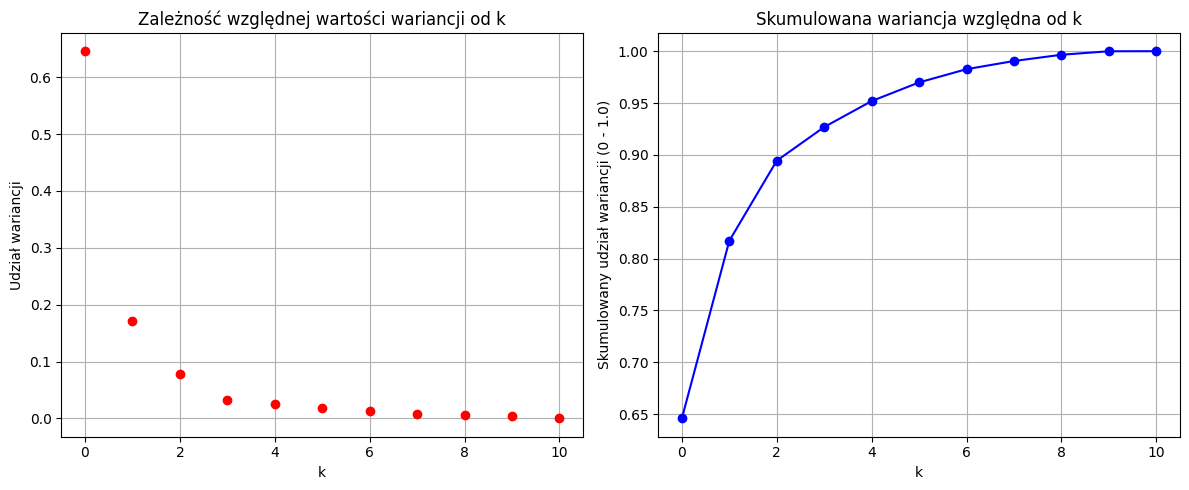

In [58]:
df = pd.read_csv('04cars-data.csv')
data = df.iloc[:,9:]

data_scaled = preprocessing.scale(data)
data_scaled.mean(axis=0)
data_scaled.std(axis=0)

pca = PCA()
X_pca = pca.fit_transform(data_scaled)

variance_rel = pca.explained_variance_ratio_
variance_abs = pca.explained_variance_
print("Wariancja względna:", variance_rel)
print("\nWariancja bezwzględna:", variance_abs)

k2_preserved = np.sum(variance_rel[:2])
k3_preserved = np.sum(variance_rel[:3])

print(f"\nWariancja zachowana dla k=2: {k2_preserved*100:.2f}%")
print(f"Wariancja zachowana dla k=3: {k3_preserved*100:.2f}%")

cumulative_variance = np.cumsum(variance_rel)

plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
plt.plot(variance_rel, 'ro')
plt.title('Zależność względnej wartości wariancji od k')
plt.xlabel('k')
plt.ylabel('Udział wariancji')
plt.grid(True)

plt.subplot(1, 2, 2) 
plt.plot(cumulative_variance, 'bo-')
plt.title('Skumulowana wariancja względna od k')
plt.xlabel('k')
plt.ylabel('Skumulowany udział wariancji (0 - 1.0)')
plt.grid(True)

plt.tight_layout()
plt.show()

Dzięki PCA możemy zredukować wielowymiarowy zbiór danych do zaledwie 2 nowych wymiarów, tracąc przy tym stosunkowo niewiele, bo około 18% pierwotnej informacji.

4. Wyświetl wartości elementów pierwszego i drugiego komponentu wiodącego wraz z odpowiadającą im nazwą cechy. Co oznaczają elementy o
wartości bliskiej zeru? Z jakimi własnościami samochodu wiążą się:

— Największe elementy pierwszego komponentu wiodącego

— Najmniejsze elementy pierwszego komponentu wiodącego

— Największe elementy drugiego komponentu wiodącego

— Najmniejsze elementy drugiego komponentu wiodącego

In [59]:
attributes = df.columns[9:]
pc1, pc2 = pca.components_[:2]

df_components = pd.DataFrame({
    'Attribute': attributes,
    'PC1': pc1,
    'PC2': pc2
})

df_components

,Attribute,PC1,PC2
0,Retail Price,0.263750,0.468509
1,Dealer Cost,0.262319,0.470147
2,Engine Size (l),0.347080,-0.015347
3,Cyl,0.334189,0.078032
4,HP,0.318602,0.292213
5,City MPG,-0.310482,-0.003366
6,Hwy MPG,-0.306589,-0.010964
7,Weight,0.336329,-0.167464
8,Wheel Base,0.266210,-0.418177
9,Len,0.256790,-0.408411


Elementy o wartości bliskiej zeru oznaczają, że cechy te nie mają praktycznie żadnego wpływu na dany komponent główny. Jest to widoczne w przypadku PC2, gdzie `City MPG` oraz `Hwy MPG` mają wartości bliskie zeru, co oznacza, że drugi kierunek wiodący jest całkowicie niezależny od ekonomii spalania samochodu. 

Największe elementy pierwszego komponentu wiodącego: 
* `Engine Size`
* `Weight`
* `Cyl`

Wiążą się one z gabarytami, masą i mocą silnika. Dodatni znak oznacza, że im większy, cięższy i mocniejszy jest samochód, tym wyższą wartość PC1 przyjmuje.

Najmniejsze elementy pierwszego komponentu wiodącego: 
* `City MPG`
* `Hwy MPG` 

Wiążą się one z wydajnością paliwową, im wyższe MPG, tym samochód pali mniej. Mają one znak ujemny, co oznacza odwrotną korelację z gabarytami - samochody duże i mocne mają niskie MPG. PC1 to zatem oś rozmiar i moc vs oszczędność paliwa.

Największe elementy drugiego komponentu wiodącego:
* `Dealer Cost`
* `Retail Price`

Wiążą się one bezpośrednio z ceną samochodu.

Najmniejsze elementy drugiego komponentu wiodącego: 
* `Wheel Base`
* `Len`
* `Width`

Są to cechy opisujące fizyczne wymiary samochodu. Ponieważ są one silnie ujemne, a ceny silnie dodatnie, PC2 różnicuje samochody na osi: drogie i relatywnie krótkie auta (np luksusowe auta sportowe) kontra tanie, bardzo długie i szerokie auta (np rodzinne minivany/kombi).

5. Dokonaj wizualizacji wektorów cech zrzutowanych na 2(3) pierwsze komponenty wiodące. Nanieś tekst z modelem samochodu na wykres. Jakie typy samochodów występują w poszczególnych częściach wykresu?

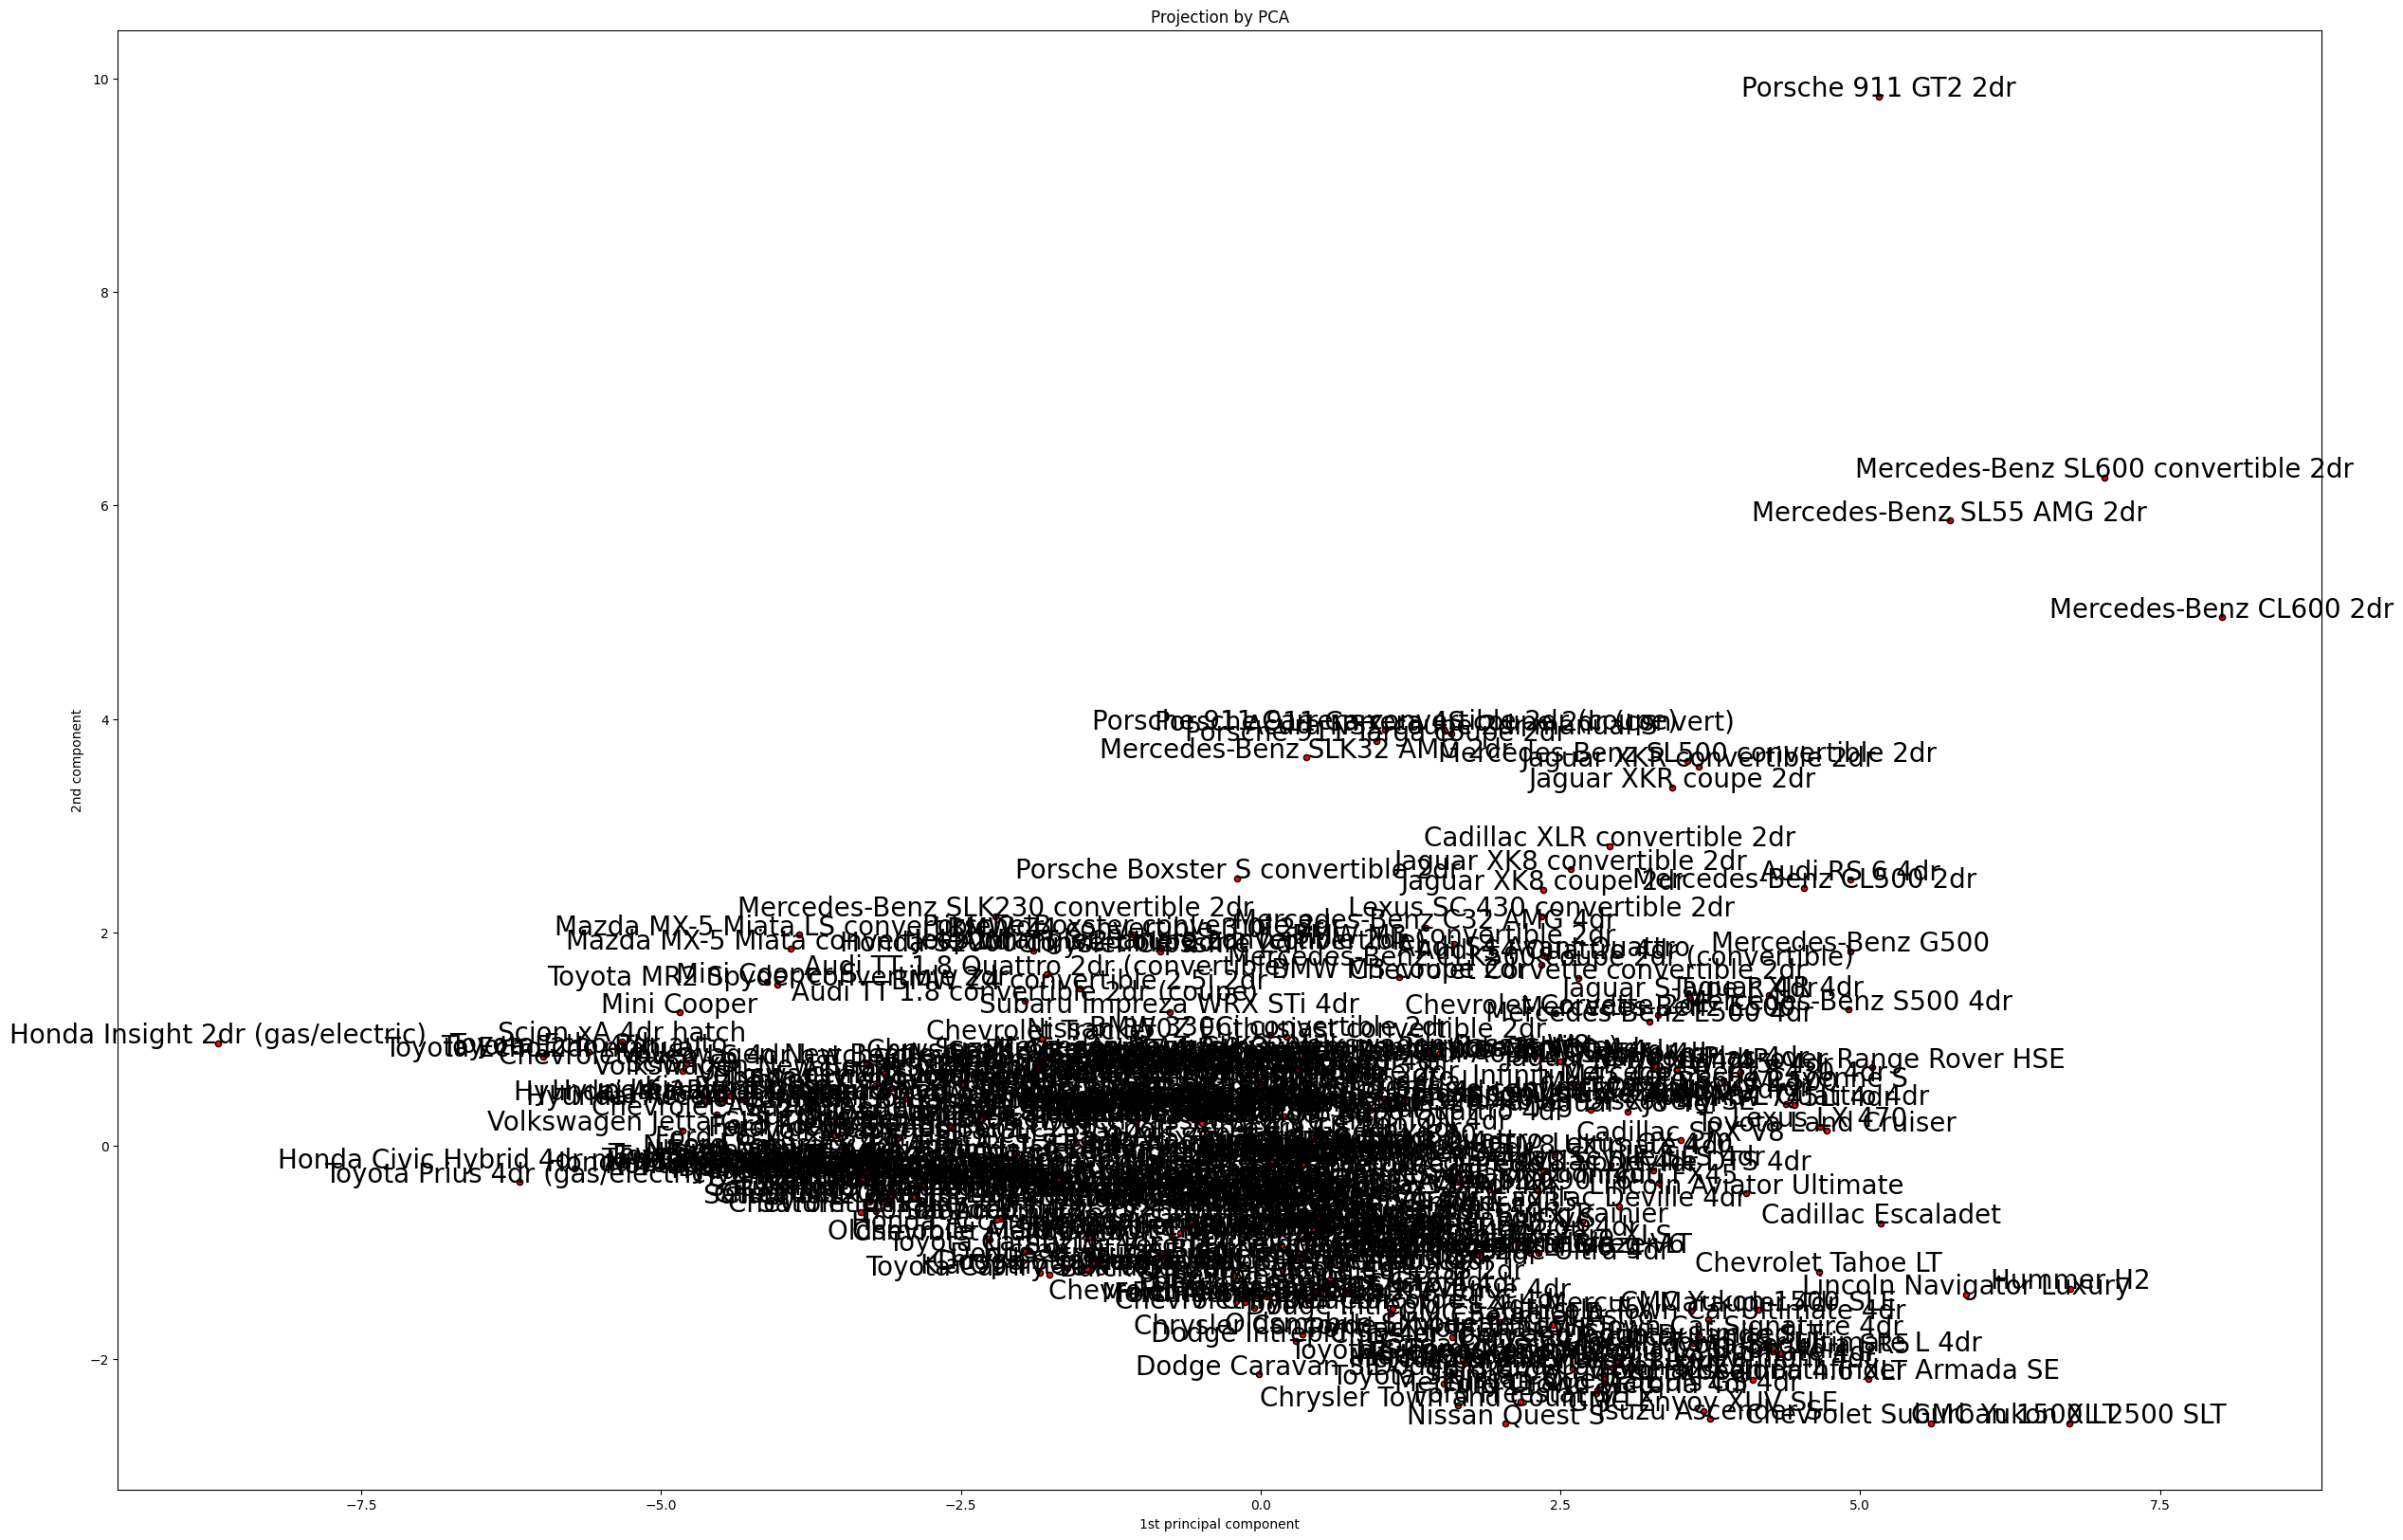

In [60]:
plt.figure(figsize=(30,20))
x = X_pca[:, 0]
y = X_pca[:, 1]
plt.scatter(x, y, c="red", s=20, edgecolor='k')
plt.title("Projection by PCA")
plt.xlabel("1st principal component")
plt.ylabel("2nd component")
labels = list(df.iloc[:,0])
for i, txt in enumerate(labels):
    plt.annotate(txt, (x[i], y[i]),ha="center",size=20)
plt.show()

**Prawy górny róg wykresu - wysokie PC1 i wysokie PC2**:

Reprezentuje bardzo drogie samochody z wielkimi i mocnymi silnikami. Są to przede wszystkim luksusowe auta sportowe o ogromnej mocy. Skrajnym przykładem w tej grupie, znajdującym się w najwyższym punkcie wykresu, jest Porsche 911.

**Prawy dolny róg - wysokie PC1 i niskie PC2**:

Grupuje długie samochody z potężnymi silnikami, charakteryzujące się jednak relatywnie niską ceną. Znajdziemy tu ogromne amerykańskie SUV-y, pickupy i vany, takie jak Hummer H2 czy Chevrolet Suburban. Pojazdy te wyróżniają się wysokim spalaniem i potężnymi gabarytami, ale kosztują ułamek tego, co sportowe auta z pierwszej grupy.

**Lewy dolny róg - niskie PC1 i niskie PC2**:

To obszar samochodów z mniejszymi silnikami, wyróżniających się dużą oszczędnością paliwa. Są to klasyczne, budżetowe auta miejskie i rodzinne skierowane do masowego klienta. W tej części wykresu grupują się najbardziej ekonomiczne pojazdy, takie jak Honda Civic, Toyota Prius czy typowe, tanie sedany.

**Lewy górny róg - niskie PC1 i wysokie PC2**:

Obejmuje drogie samochody o relatywnie małych, oszczednych silnikach. Ta część wykresu jest dość pusta, ponieważ takie połączenie cech występuje w tym zbiorze rzadko. Reprezentuje ona pojazdy klasy premium oraz modele wysoce zaawansowane technologicznie, nastawione na ekonomię jazdy (wydaje mi się, że można byłoby tu wrzucić Teslę:).

6. Na tym samym wykresie w 2D przedstaw zbiór danych o zredukowanym
rozmiarze wraz z wizualicacją cech zrzutowanych na 2 pierwsze komponenty wiodące (biplot, patrz Rysunek 3). Co pokazuje tego typu wizualizacja?

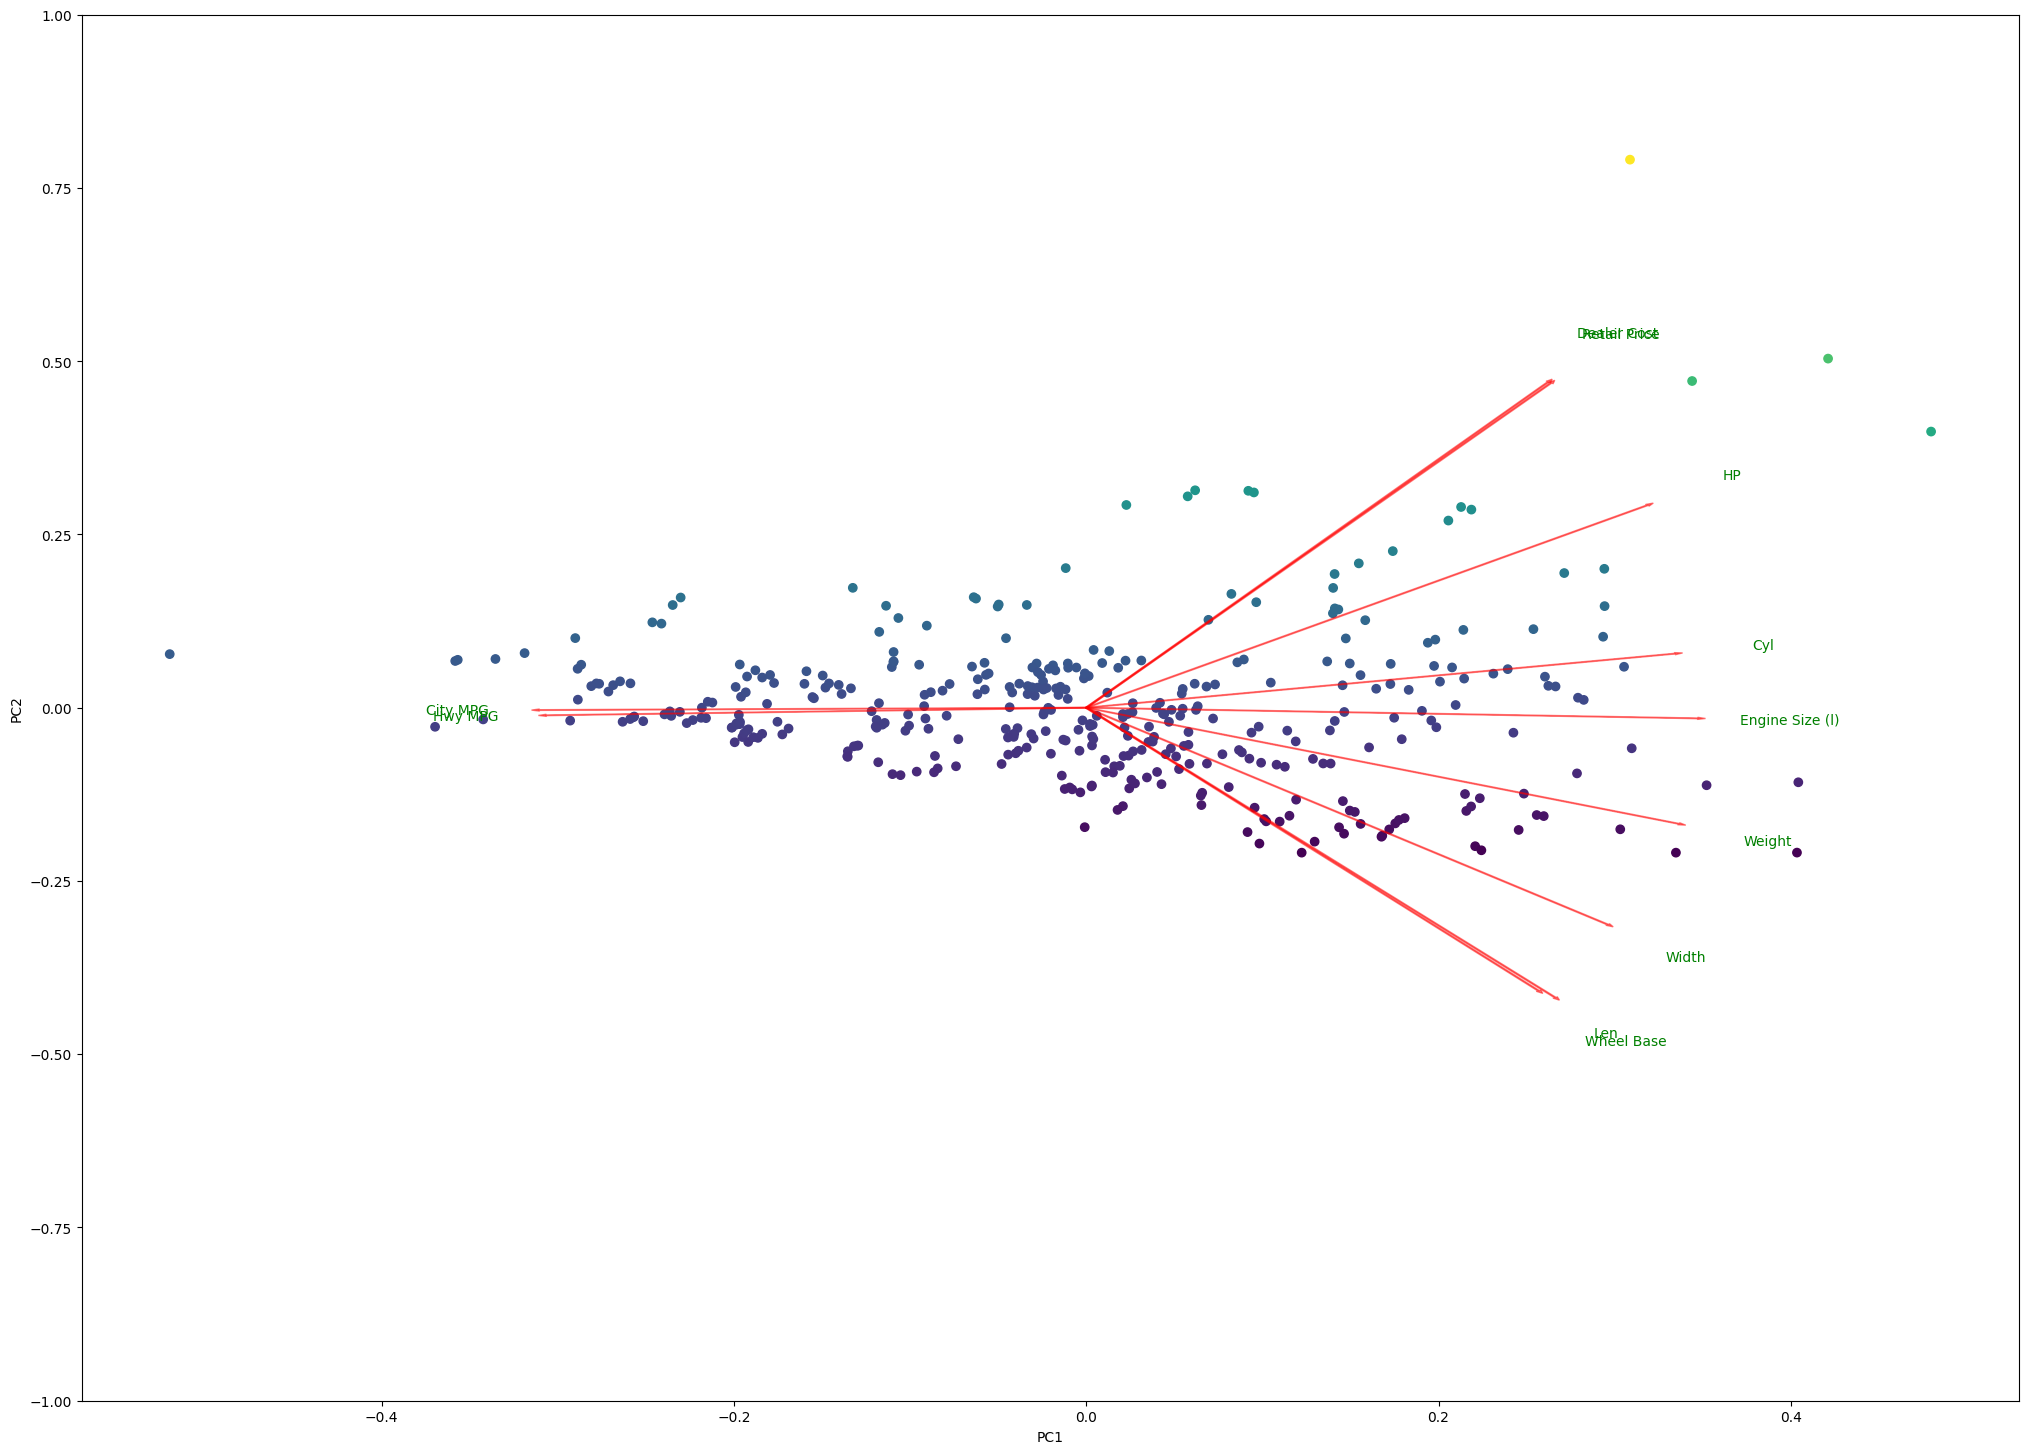

In [61]:
def myplot(score,coeff,labels=None):
    plt.figure(figsize=(25,18))
    plt.xlabel("PC{}".format(1))
    plt.ylabel("PC{}".format(2))
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    plt.scatter(xs * scalex,ys * scaley, c = y)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color = 'r', alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0] * 1.15, coeff[i,1] * 1.15, "Var" + str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0] * 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')

myplot(X_pca[:,0:2],np.transpose(pca.components_[0:2, :]),attributes)
axes = plt.gca()
axes.set_ylim([-1.0,1.0])
plt.show()

Wizualizacja pokazuje relacje między pierwotnymi cechami a nowymi komponentami wiodącymi, a także pozwala na interpretację rozkładu samych obserwacji. Z wykresu możemy odczytać trzy kluczowe informacje:

* **Kierunek i korelacja cech**

Kąt między strzałkami informuje nas o korelacji między oryginalnymi zmiennymi. Strzałki wskazujące w podobnym kierunku (np. Dealer Cost i Retail Price albo Len, Width i Weight) oznaczają silną, dodatnią korelację tych cech.
Strzałki skierowane w przeciwnych kierunkach (np. City MPG celujące w lewo oraz Engine Size lub Weight celujące w prawo) oznaczają silną korelację ujemną (duże i ciężkie auta mają małe MPG, czyli dużo palą).

* **Znaczenie cech**

Im dłuższa strzałka, tym lepiej dana cecha jest reprezentowana w przestrzeni dwóch pierwszych komponentów, tj. ma na nie większy wpływ. Cechy z bardzo krótkimi wektorami byłyby słabo powiązane z PC1 i PC2.

* **Profilowanie obserwacji**

Pozycja konkretnego punktu względem wektorów cech pozwala odgadnąć jego parametry. Jeśli kropka znajduje się daleko w kierunku, w którym wskazuje strzałka Retail Price (prawy górny róg), możemy być pewni, że jest to bardzo drogi samochód. Jeśli leży w kierunku strzałki City MPG (lewa strona), wiemy, że to auto bardzo oszczędne.

## Budowa eigenfaces w oparciu o zbiór danych LFW

1. Korzystając z biblioteki scikit-learn wczytaj podzbiór zbioru danych LFW składający się z osób reprezentowanych przez co najmniej 50 różnych zdjęć (fetch lfw people()). W ten sposób otrzymasz zbiór zdjęć 12 różnych osób.

In [62]:
lfw_people = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Liczba wszystkich zdjęć: {n_samples}")
print(f"Rozdzielczość pojedynczego zdjęcia: {h} x {w}")
print(f"Liczba cech (h * w): {X.shape[1]}")
print(f"Liczba unikalnych osób: {n_classes}")
print("Osoby:")
for i, name in enumerate(target_names):
    print(f"{i+1}. {name}")

Liczba wszystkich zdjęć: 1560
Rozdzielczość pojedynczego zdjęcia: 50 x 37
Liczba cech (h * w): 1850
Liczba unikalnych osób: 12
Osoby:
1. Ariel Sharon
2. Colin Powell
3. Donald Rumsfeld
4. George W Bush
5. Gerhard Schroeder
6. Hugo Chavez
7. Jacques Chirac
8. Jean Chretien
9. John Ashcroft
10. Junichiro Koizumi
11. Serena Williams
12. Tony Blair


2. Podziel otrzymany zbiór danych na część treningową i testową (0.7, 0.3)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape[0]} zdjęć")
print(f"X_test: {X_test.shape[0]} zdjęć")

X_train: 1092 zdjęć
X_test: 468 zdjęć


3. Dla zbioru treningowego, oblicz PCA i opierając się na otrzymanych w ten sposób 100 pierwszych komponentach głównych dokonaj redukcji wymiarowości do 100 dla zbioru treningowego i testowego.

In [64]:
n_components = 100
pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Zredukowany wymiar X_train: {X_train_pca.shape}")
print(f"Zredukowany wymiar X_test: {X_test_pca.shape}")

Zredukowany wymiar X_train: (1092, 100)
Zredukowany wymiar X_test: (468, 100)


4. Korzystając ze zbioru treningowego o zredukowanej wymiarowości, wytrenuj dwa wybrane modele klasyfikacji (np. MLP, SVM, RF, LightGBM) oraz oblicz dokładność klasyfikacji uzyskaną dla każdej z 12 klas na zbiorze testowym. Zamieść w raporcie uzyskane wartości: precision, recall, f1-score. Jak zmieniają się uzyskane wyniki w przypadku redukcji do 50 wymiarów? Wybierz optymalną wymiarowość w oparciu o scree plot.

In [65]:
pca_50 = PCA(n_components=50, whiten=True, random_state=42)
X_train_pca_50 = pca_50.fit_transform(X_train)
X_test_pca_50 = pca_50.transform(X_test)

print("Wyniki SVC dla 100 wymiarów")

svm_clf = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_clf.fit(X_train_pca, y_train)
y_pred_svm = svm_clf.predict(X_test_pca)
print("\nRaport klasyfikacji dla SVM:")
print(classification_report(y_test, y_pred_svm, target_names=target_names))

print("\nWyniki SVC dla 50 wymiarów")

svm_clf_50 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_clf_50.fit(X_train_pca_50, y_train)
y_pred_svm_50 = svm_clf_50.predict(X_test_pca_50)
print("\nRaport klasyfikacji dla SVM:")
print(classification_report(y_test, y_pred_svm_50, target_names=target_names))


print("\nWyniki MLP dla 100 wymiarów")

mlp_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_clf.fit(X_train_pca, y_train)
y_pred_mlp = mlp_clf.predict(X_test_pca)
print("\nRaport klasyfikacji dla MLP:")
print(classification_report(y_test, y_pred_mlp, target_names=target_names))

print("\nWyniki MLP dla 50 wymiarów")

mlp_clf_50 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp_clf_50.fit(X_train_pca_50, y_train)
y_pred_mlp_50 = mlp_clf_50.predict(X_test_pca_50)
print("\nRaport klasyfikacji dla MLP:")
print(classification_report(y_test, y_pred_mlp_50, target_names=target_names))

Wyniki SVC dla 100 wymiarów

Raport klasyfikacji dla SVM:
                   precision    recall  f1-score   support

     Ariel Sharon       0.94      0.70      0.80        23
     Colin Powell       0.77      0.86      0.81        71
  Donald Rumsfeld       0.69      0.69      0.69        36
    George W Bush       0.78      0.92      0.84       159
Gerhard Schroeder       0.72      0.79      0.75        33
      Hugo Chavez       1.00      0.52      0.69        21
   Jacques Chirac       0.89      0.50      0.64        16
    Jean Chretien       0.92      0.69      0.79        16
    John Ashcroft       0.79      0.69      0.73        16
Junichiro Koizumi       1.00      0.50      0.67        18
  Serena Williams       1.00      0.56      0.72        16
       Tony Blair       0.69      0.77      0.73        43

         accuracy                           0.78       468
        macro avg       0.85      0.68      0.74       468
     weighted avg       0.80      0.78      0.78       

Można zauważyć, że redukcja liczby wymiarów ze 100 do 50 nieznacznie poprawiła ogólną accuracy obu trenowanych modeli, zamiast ją pogorszyć. W przypadku modelu SVM ogólna dokładność wzrosła z 78% na 79%, a w przypadku MLP z 79% na 81%. Poprawie uległo również średnia f1-score dla wielu klas, w tym dla najliczniejszej grupy w zbiorze testowym czyli Georga W. Busha - wzrost f1-score w modelu MLP z 0.89 na 0.91. Można wnioskować, że wynik ten śiwadczy o tym, że 100 komponentów głownych zawierało zbyt zbędnych informacji (szumu). Mogło to wynikać np z różnic w oświetelniu czy tła zdjęć. Zredukowanie danych do 50 komponentow sprawiło, że odrzuciliśmy szum informacyjny, pozostawiając modelom wyłącznie najważniejsze, czyste cechy twarzy. Dzięki temu algorytmy lepiej poradziły sobie z uogólnianiem wiedzy na zbiorze testowym.

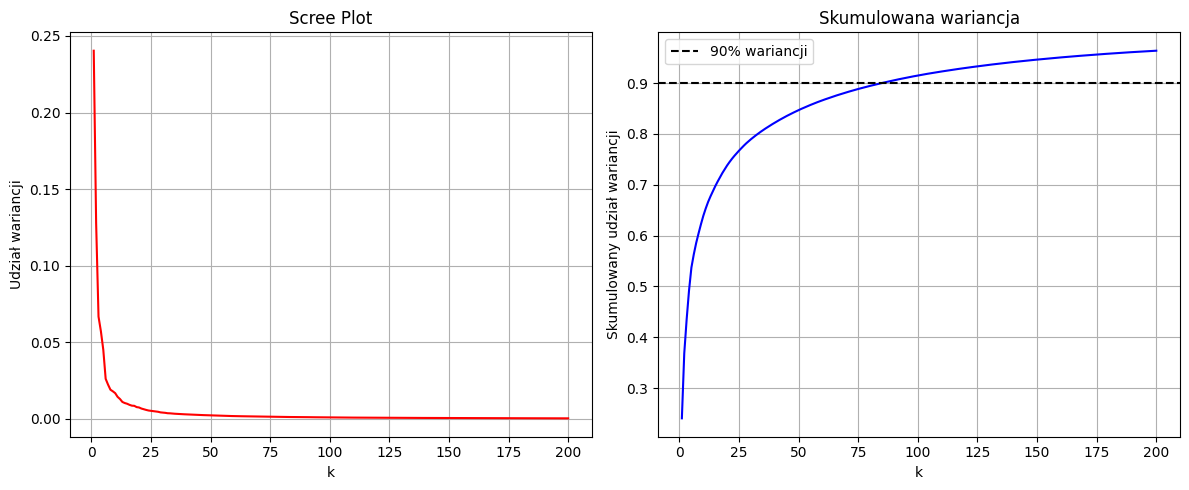

In [66]:
pca_full = PCA(n_components=200, whiten=True, random_state=42)
pca_full.fit(X_train)

variance_rel = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_rel)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 201), variance_rel, 'r-')
plt.title('Scree Plot')
plt.xlabel('k')
plt.ylabel('Udział wariancji')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, 201), cumulative_variance, 'b-')
plt.axhline(y=0.90, color='k', linestyle='--', label='90% wariancji')
plt.title('Skumulowana wariancja')
plt.xlabel('k')
plt.ylabel('Skumulowany udział wariancji')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Wykres osypiska prezentuje udział wariancji niesiony przez pojedyncze, kolejne komponenty główne. Obserwujemy na nim bardzo gwałtowny spadek dla pierwszych kilkunastu kierunków. Punkt przegięcia, po którym spadek drastycznie zwalnia znajduje się w okolicach k równego ~15-25. Powyżej k=50 krzywa staje się niemal całkowicie płaska i bliska zeru. Oznacza to, że komponenty o numerach powyżej 50 wnoszą bardzo małe ilości nowych informacji.

Wykres ten pokazuje łączną ilość zachowanej informacji w zależności od liczby wymiarów. Przecięcie niebieskiej krzywej z czarną, przerywaną linią pokazuje, że aby spełnić popularną regułę zachowania 90% oryginalnej wariancji, należałoby wybrać około 85 komponentów.

Wybór optymalnej wymiarowości jest kompromisem między wykresem osypiska a regułą 90%. Biorac pod uwagę wyniki z poprzedniego punktu, gdzie klasyfikatory SVM i MLP osiągnęły lepszą dokładność dla 50 wymiarów niż dla 100, za optymalną wymiarowość należy uznać k = 50. Scree plot tłumaczy to zjawisko, gdyż dla k = 50 zachowujemy wciąż wiekszość kluczowych informacji ok. 80-85% wariancji, podczas gdy komponenty od 50 w górę, które mają niemal zerową wariancję, stanowią szum, który mógł spowodować przeuczenie modeli dla k = 100.

5. Wyświetl 20 pierwszych komponentów głównych (po uprzednim przeskalowaniu) w formie obrazu w skali szarości (eigenfaces). W jaki sposób można zinterpretować działanie eigenfaces w kontekście redukcji wymiarowości wcześniej nie widzianego zdjęcia (przykładu testowego)? Jakie cechy ekstrahują poszczególe eigenfaces?

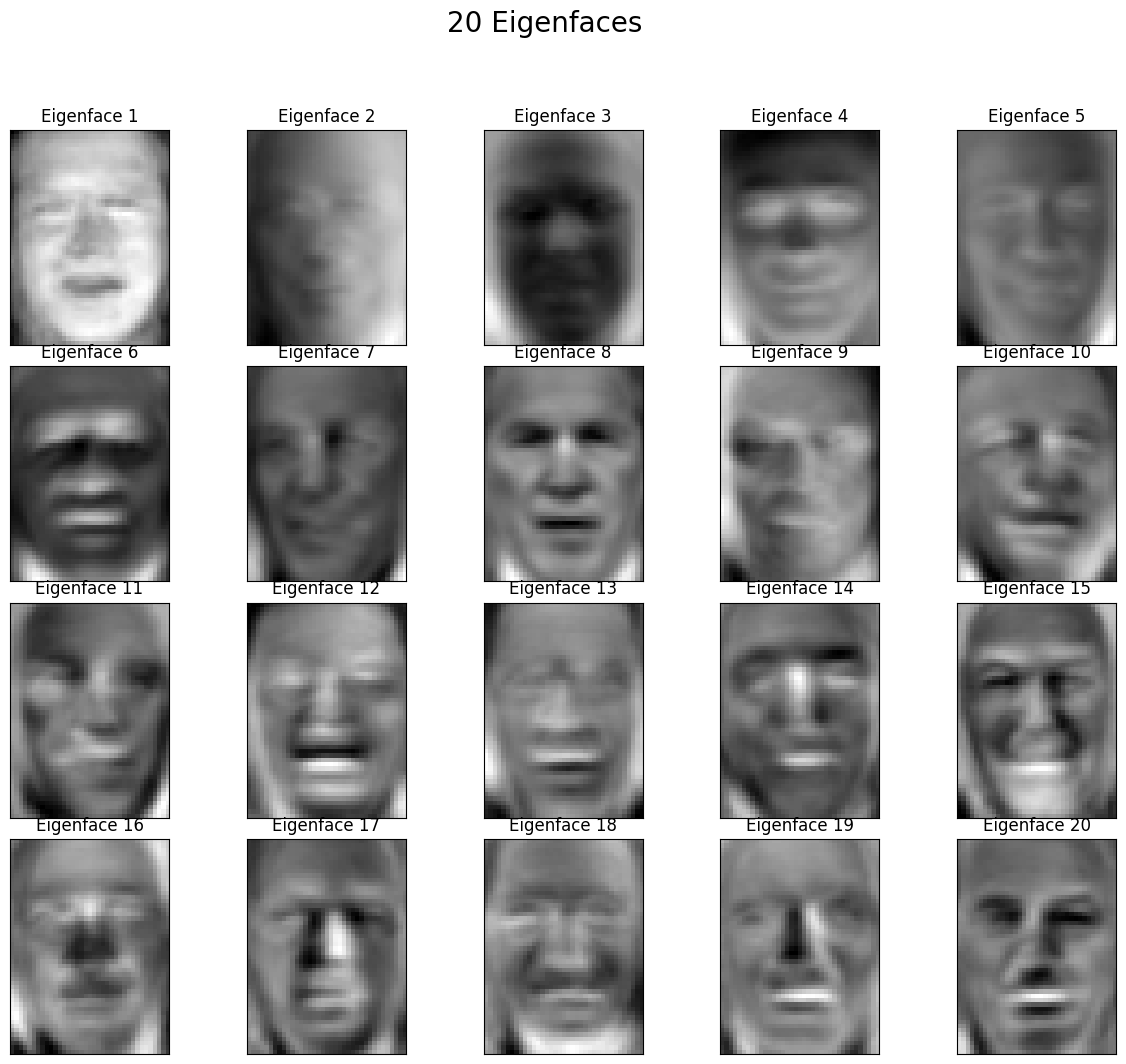

In [67]:
eigenfaces = pca.components_[:20]

fig, axes = plt.subplots(4, 5, figsize=(15, 12),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(eigenfaces[i].reshape(h, w), cmap='gray')
    ax.set_title(f"Eigenface {i+1}")

plt.suptitle("20 Eigenfaces", fontsize=20)
plt.show()

Działanie eigenfaces opiera się na koncepcji kombinacji liniowej. Wygenerowane twarze własne tworzą "bazę szablonów". Gdy algorytm otrzymuje nowe, wcześniej nie widziane zdjęcie testowe, nie musi już zapisywać wartości tysięcy pojedynczych pikseli. Każda ludzka twarz może być pojmowana jako kombinacja tych standardowych twarzy. PCA sprawdza, jak bardzo to nowe zdjęcie jest podobne do poszczególnych szablonów i oblicza dla nich "wagi". Redukcja wymiarowości polega na tym, że zdjęcie zostaje zapisane jako krótki wektor wag (np. 50 liczb), określający, że dana twarz odpowiada np. w 20% Eigenface nr 1, w 5% Eigenface nr 2 itd. Na podstawie tych kilkudziesięciu współczynników można zrekonstruować przybliżony wygląd twarzy.

Jeśli chodzi o to, jakie cechy ekstrahują poszczególne eigenfaces to wydaje mi się, że pierwsze z nich (te najistotniejsze) ekstrahują najsilniejsze, globalne cechy twarzy, takie jak ogólny zarys głowy, odcięcie tła od sylwetki oraz kierunek padania światła, co pozwala algorytmowi PCA uniezależnić się od warunków oświetleniowych na zdjęciu. Kolejne eigenfaces ekstrahują konkretne cechy anatomiczne. Kodują takie informacje jak szerokość nosa, zarys oczodołów, układ kości policzkowych, obecność okularów czy linię włosów i czoła. Dalsze eigenfaces (z zakresu 12-20) ekstrahują bardzo drobne, specyficzne detale, takie jak mimikę, zmarszczki czy specyficzne rysy twarzy.